# Notebook 3: LLM trope classification and false negative analysis

This notebook tests whether an LLM can classify the manosphere tropes used in my capstone, and where it breaks down. The analysis supports RQ3 by testing which ideological tropes can be classified reliably and which failures require qualitative analysis.

The method builds on Bunt et al. (2025) prompt-validation workflow from the NLP classes: start with a simple MinZero prompt, check the errors, refine the prompt, then test.

This methodology treats LLM classification as a measurement problem rather than as an automatic source of truth. The four trope categories must first be conceptually defined, then validated against hand-coded examples. This follows the taught NLP workflow of simple prompting, development-set error analysis, prompt refinement and  testing. It also follows broader guidance that automated text classification should be carefully validated against human-coded material, while recognising that a single-coder gold standard limits what the scores can prove (Locke, 2012; Song et al., 2020; Törnberg, 2024).

The validation set contains 100 hand-coded posts: 35 development posts for prompt refinement and 65 held-out test posts for confirmatory evaluation. The 12 qualitative mechanism-analysis cases used later in the capstone are separate from this validation set. Across validation and qualitative phases, the project therefore uses 112 coded cases in total.

The main decision this notebook makes is which trope classifiers are safe to use. Prescription is strong enough to be treated as validated. Rejection is useful but weaker, so I report it cautiously. Crisis and Hate are excluded from prevalence claims because their validation scores are too weak or too sparse.



## Setup

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# install packages used by the LLM validation workflow
!pip install openai groq scikit-learn tqdm pandas

  Using cached openai-2.41.1-py3-none-any.whl.metadata (32 kB)
  Using cached groq-1.4.0-py3-none-any.whl.metadata (16 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jiter-0.15.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.2 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
Using cached openai-2.41.1-py3-none-any.whl (1.4 MB)
Using cached groq-1.4.0-py3-none-any.whl (143 kB)
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached jiter-0.15.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (349 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# set up libraries
import pandas as pd
import time
import os
import re
import warnings
from IPython.display import Markdown, display

# Groq API client
from groq import Groq

# evaluation metrics
from sklearn.metrics import (
    # f1 score, https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
    precision_score, recall_score, f1_score,
    # cohen's kappa, classifier-coder agreement, https://scikit-learn.org/stable/modules/generated/sklearn.metrics.cohen_kappa_score.html
    accuracy_score, cohen_kappa_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# progress bar
from tqdm.auto import tqdm

# plotting
import matplotlib.pyplot as plt
import numpy as np

## Reproducibility 

The classification cells use the **Groq API** with **Llama 3.3 70B** at temperature = 0. I saved the final predictions to CSV so the analysis and figures can be rerun without calling the API every time.

I used Llama 3.3 70B because the labelled set is small and many titles depend on implication rather than obvious keywords. The LLM outputs are therefore treated as something to validate, not as ground truth.


In [6]:
# initialise Groq client
# load api key from local environment
client = Groq(api_key=os.environ.get('GROQ_API_KEY'))

In [7]:
# temperature 0 keeps the classifier as consistent as possible
TEMPERATURE = 0

In [8]:
# apply one trope-specific prompt to a list of Reddit titles
# llama model returns y/n label for each title
# the function means it can be used for every trope 

def classify_batch(texts, prompt, model="llama-3.3-70b-versatile", delay=0.1):
    predictions = []

    for text in tqdm(texts, desc="Classifying"):
        # retry in case the api rate-limits
        for attempt in range(3):
            try:
                response = client.chat.completions.create(
                    model=model,
                    messages=[
                        {"role": "system", "content": prompt},
                        {"role": "user", "content": str(text)}
                    ],
                    temperature=TEMPERATURE,
                    max_tokens=10
                )
                raw = response.choices[0].message.content.strip()
                # normalise for formatting variations
                predictions.append('Yes' if 'yes' in raw.lower() else 'No')
                break
            except Exception as e:
                warnings.warn(f'attempt {attempt + 1} failed: {e}')
                time.sleep(2 ** attempt)
        else:
            # if all attempts fail, mark as no and continue
            warnings.warn('unresolved after retries - defaulting to No')
            predictions.append('No')
        time.sleep(delay)

    return predictions

In [9]:
# calculate validation metrics for binary labels: from 0/1 to y/n predictions
# f1 shows how well the model balances precision and recall
# cohen's kappa is stricted because it adjusts for agreement that could happen by chance
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.cohen_kappa_score.html

def calculate_metrics(y_true, y_pred, positive_label='Yes'):
    
    # convert labels to binary 0/1
    def to_bin(val):
        # if the value is numeri, keep it as an integer
        if isinstance(val, (int, float)):
            return int(val)
            # if the value is astring treat the positive label as 1 and anything else 0
        return 1 if str(val) == positive_label else 0

    # convert the human coded column and the model prediction column
    yt = [to_bin(y) for y in y_true]
    yp = [to_bin(y) for y in y_pred]
    
    return {
        'f1':        round(f1_score(yt, yp, zero_division=0), 3),
        'precision': round(precision_score(yt, yp, zero_division=0), 3),
        'recall':    round(recall_score(yt, yp, zero_division=0), 3),
        'kappa':     round(cohen_kappa_score(yt, yp), 3)
    }

In [10]:
# functions for error analysis and display
# help inspect where the model agrees or disagrees with the hand-coded labels

def find_errors(df, true_col, pred_col, positive_label='Yes', error_type='all'):
    """
    Pull out different kinds of model errors.

    true_col = human-coded label column
    pred_col = model prediction column

    error_type options:
    - 'false_positive': model says present, human coding says absent
    - 'false_negative': model says absent, human coding says present
    - 'all': any disagreement between human coding and model prediction
    """

    def is_pos(val):
        # some columns use 0/1 labels while model predictions usually use y/n
        # converts both formats into true or false
        if isinstance(val, (int, float)):
            return bool(val)

        return str(val) == positive_label

    # convert human-coded labels and model predictions into t/f series
    # comparison easier
    true_is_positive = df[true_col].apply(is_pos)
    pred_is_positive = df[pred_col].apply(is_pos)

    if error_type == 'false_positive':
        # false positive:
        # the human coding says the trope is absent
        # but the model predicts that it is present
        return df[(~true_is_positive) & pred_is_positive]

    elif error_type == 'false_negative':
        # false negative:
        # the human coding says the trope is present
        # but the model predicts that it is absent
        return df[true_is_positive & (~pred_is_positive)]

    else:
        # if they all disagree
        # any case where the human coding and model prediction do not match
        return df[true_is_positive != pred_is_positive]


def metrics_table(results_dict):
    # format as table.
    # each row is a trope, column validation metrics.
    return pd.DataFrame(results_dict).T[['f1', 'precision', 'recall', 'kappa']]

## 1. Gold standard and data splitting

I hand-coded 100 validation posts across four tropes derived from Ging (2019) and Tanner & Gillardin (2025). These were split into a development set of 35 posts for prompt refinement and a held-out test set of 65 posts for confirmatory evaluation.

This is separate from the 12 qualitative cases used later in the capstone. Those cases are for explaining mechanisms, not for validating the classifier. Across validation and qualitative phases, the project uses 112 coded cases in total.

There is an important limitation here: this is a single-coder gold standard. The scores reflect performance relative to my coding decisions, not to an objective ground ruth.


In [13]:
# load hand coded gold standard
# this follows the taught NLP workflow: develop prompt on one split
# the human coded examples are split into two parts: the development set - used to refine the prompts
# the test set is kept seperate and used to check final performance

gs = pd.read_csv('gold_standard_FINAL.csv')

# stratified seeded split so development and test sets keep a similar class balance
# random_state=42 keeps the split reproducible
# rejection is used for stratification because it is the most common trope
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

from sklearn.model_selection import train_test_split
df_dev, df_test = train_test_split(
    # stratify by rejection is the most common tropes
    gs, test_size=0.65, stratify=gs['Rejection'], random_state=42
)
df_dev  = df_dev.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

pd.DataFrame({'set': ['development', 'test'], 'n': [len(df_dev), len(df_test)]})

,set,n
0,development,35
1,test,65


## 2. Prompt development 

This section starts with simple prompts, checks the development-set errors, and then tightens the prompts where needed. The test set is not used during this stage.

**MinZero:** minimal definition, no examples.

**Error analysis:** check whether the mistakes follow a pattern.

**MaxZero:** refined prompt with clearer positive and negative rules.

Only the development set is used here. The test set stays locked until Section 3.


### MinZero prompts

In [14]:
# minzero prompts, minimal definition, no examples
# this starts simple and with development-set errors becomes refineed
# this follows the taught prompt-validation workflow: start simple, inspect error, then refine

# following the taught dev/test workflow Part 5: start with minzero
minzero_prompts = {}

minzero_prompts['Rejection'] = """You are a research assistant.
Identify whether the following Reddit post title contains the 'Rejection' trope:
narratives where men are discarded, replaced, exploited, or socially/sexually excluded.
Respond with ONLY 'Yes' or 'No'."""

minzero_prompts['Crisis'] = """You are a research assistant.
Identify whether the following Reddit post title contains the 'Crisis' trope:
claims that men as a group are being systemically harmed by the state or feminists.
Respond with ONLY 'Yes' or 'No'."""

minzero_prompts['Hate'] = """You are a research assistant.
Identify whether the following Reddit post title contains the 'Hate' trope:
explicit dehumanisation or vitriol portraying women as an inherently malicious class.
Respond with ONLY 'Yes' or 'No'."""

minzero_prompts['Prescription'] = """You are a research assistant.
Identify whether the following Reddit post title contains the 'Prescription' trope:
direct advice, rules, or actionable instructions on how men should act.
Respond with ONLY 'Yes' or 'No'."""

In [15]:
# evaluate minzero prompts on the development set
minzero_results = {}
for trope, prompt in minzero_prompts.items():
    preds = classify_batch(df_dev['Title'].tolist(), prompt)
    df_dev[f'minzero_{trope}'] = preds
    minzero_results[trope] = calculate_metrics(
        df_dev[trope].tolist(), preds
    )

metrics_table(minzero_results)

Classifying:   0%|          | 0/35 [00:00<?, ?it/s]

Classifying:   0%|          | 0/35 [00:00<?, ?it/s]

Classifying:   0%|          | 0/35 [00:00<?, ?it/s]

Classifying:   0%|          | 0/35 [00:00<?, ?it/s]

,f1,precision,recall,kappa
Rejection,0.667,0.643,0.692,0.458
Crisis,0.000,0.000,0.000,-0.050
Hate,0.000,0.000,0.000,0.000
Prescription,0.476,0.625,0.385,0.269


### Interpretation: 

Before refining the prompts, I check whether the errors are random or patterned.

The main issue is Rejection. Some positive Rejection cases do not use obvious manosphere vocabulary. They work through framing and presupposition, which is exactly the kind of language this project is interested in.


In [30]:
# error check before prompt refinement
# false positives show where the prompt over-detects a trope
# false negatives show where the prompt misses a trope
# these errors guide the refined MaxZero prompts below

trope = 'Rejection'

fp = find_errors(
    df_dev,
    true_col=trope,
    pred_col=f'minzero_{trope}',
    error_type='false_positive'
)

fn = find_errors(
    df_dev,
    true_col=trope,
    pred_col=f'minzero_{trope}',
    error_type='false_negative'
)

error_counts = pd.Series({
    'false_positives': len(fp),
    'false_negatives': len(fn)
}, name='count')

display(error_counts.to_frame())
fn[['Title']].head(5)

,count
false_positives,5
false_negatives,4


,Title
3,National Geographic Agrees: The Human Alpha Ma...
11,"Single women are not ""the happiest demographic..."
14,The widespread research declaring that women a...
27,Women don't understand why promiscuity is unde...


### MaxZero prompts

In [17]:
# maxzero prompts refined from minzero error analysis
# the aim is to make the trope definition clear; rather than make the prompt more persuasive
maxzero_prompts = {}

maxzero_prompts['Rejection'] = """You are a sociology research assistant. Identify the 'Rejection' trope.

DEFINITION:
Narratives where men are discarded, replaced, exploited, or socially/sexually excluded.

STRICT POSITIVE RULES (Code 'Yes'):
1. SOCIAL DYNAMICS: Discussions about the mechanics of rejection, such as 'hard no' vs 'not right now', or women changing how they feel about a man.
2. MARKET DYNAMICS: 'Why aren't men/women attracted to X'. These explain why certain men are rejected from the 'market'.
3. TERMINOLOGY: Discussions about the language used to describe these rejections (e.g., 'Toxic Terminology').
4. SLANG: 'divorce-raped' or 'alimony' are always 'Yes'.

STRICT NEGATIVE CONSTRAINTS (Code 'No'):
1. VAGUE TITLES: Do not code titles like 'True Story... Sadly' as 'Yes' unless they explicitly mention men being rejected.
2. GENERAL ADVICE: Strategy like 'how to talk' is 'No' UNLESS it centers on avoiding being discarded.

Respond with ONLY 'Yes' or 'No'."""

maxzero_prompts['Prescription'] = """You are a sociology research assistant. Identify the 'Prescription' trope.

DEFINITION:
The text provides direct advice, strategy, 'rules' for behavior, or actionable instructions on how men should act.

STRICT POSITIVE RULES (Code 'Yes'):
1. STRATEGY: Titles offering tips (e.g., 'Afraid of being denied? Try this!').
2. INSTRUCTIONS: Direct commands (e.g., 'Language game: Use the imperative form').
3. LOGIC/WHY: Explaining a 'rule' of dating.

STRICT NEGATIVE CONSTRAINTS (Code 'No'):
1. VENTING: Complaints without a 'solution' or 'rule' are NOT Prescription.
2. NEWS: Reporting on events without giving advice is NOT Prescription.

Respond with ONLY 'Yes' or 'No'."""

maxzero_prompts['Crisis'] = """You are a sociology researcher. Identify the 'Crisis' trope.

DEFINITION:
Claims that men as a group are being systemically, legally, or institutionally harmed by the state or feminists.

STRICT INSTRUCTIONS (Code 'Yes'):
1. INSTITUTIONAL/LEGAL: Laws, bills, or court outcomes that 'feminists' influenced to hurt men.
2. SYSTEMIC THREAT: Claims that men's rights are being 'systematically' stripped away.

STRICT NEGATIVE CONSTRAINTS (Code 'No'):
1. PERSONAL: One guy being sad about a breakup is NOT a crisis.

Respond with ONLY 'Yes' or 'No'."""

maxzero_prompts['Hate'] = """You are a sociology researcher. Identify the 'Hate' trope.

DEFINITION:
Explicit dehumanisation, negative biological labeling, or vitriol portraying women as an inherently malicious class.

STRICT INSTRUCTIONS (Code 'Yes'):
1. DEHUMANISATION: Portraying women as 'biological parasites', 'toxic', or 'naturally deceptive'.
2. MANOSPHERE LABELS: Using labels to categorize women as an 'enemy' class.

STRICT NEGATIVE CONSTRAINTS (Code 'No'):
1. ANNOYANCE: Simply being annoyed by a specific person is NOT the trope unless generalised to ALL women.

Respond with ONLY 'Yes' or 'No'."""

In [18]:
# evaluate maxzero prompts on the development set

maxzero_results = {}
for trope, prompt in maxzero_prompts.items():
    preds = classify_batch(df_dev['Title'].tolist(), prompt)
    df_dev[f'maxzero_{trope}'] = preds
    maxzero_results[trope] = calculate_metrics(
        df_dev[trope].tolist(), preds
    )

metrics_table(maxzero_results)

Classifying:   0%|          | 0/35 [00:00<?, ?it/s]

Classifying:   0%|          | 0/35 [00:00<?, ?it/s]

Classifying:   0%|          | 0/35 [00:00<?, ?it/s]

Classifying:   0%|          | 0/35 [00:00<?, ?it/s]

,f1,precision,recall,kappa
Rejection,0.759,0.688,0.846,0.591
Prescription,0.880,0.917,0.846,0.813
Crisis,0.000,0.000,0.000,-0.029
Hate,0.000,0.000,0.000,0.000


## 3. Validation 

This section runs the refined prompts once on the test set. I do not change the prompts after seeing these results.

The point is to avoid treating the test set like another development set.

In [19]:
# following the taught validation workflow Part 3: one run, no changes after this
# prompts are not changes after this point
confirmatory_results = {}
for trope, prompt in maxzero_prompts.items():
    preds = classify_batch(df_test['Title'].tolist(), prompt)
    df_test[f'pred_{trope}'] = preds
    confirmatory_results[trope] = calculate_metrics(
        df_test[trope].tolist(), preds
    )

# save test predictions
df_test.to_csv('gs_test_with_predictions.csv', index=False)

metrics_table(confirmatory_results)

Classifying:   0%|          | 0/65 [00:00<?, ?it/s]

Classifying:   0%|          | 0/65 [00:00<?, ?it/s]

Classifying:   0%|          | 0/65 [00:00<?, ?it/s]

Classifying:   0%|          | 0/65 [00:00<?, ?it/s]

,f1,precision,recall,kappa
Rejection,0.769,0.714,0.833,0.617
Prescription,0.842,0.889,0.800,0.777
Crisis,0.400,0.500,0.333,0.377
Hate,0.471,0.364,0.667,0.399


### Interpretation

Prescription holds up best from development to test. Rejection drops more noticeably, so I keep it as indicative rather than fully validated. Crisis and Hate are not strong enough to report as prevalence findings.

This is useful in itself. The weaker Rejection result aligns with the broader argument that some manosphere language now resembles generic dating or self-improvement advice, which gives the classifier fewer surface clues.

In [20]:
tropes = ['Prescription', 'Rejection', 'Crisis', 'Hate']

# compare prompt performance on development set
# dev - after prompt refinement
# test - confirmatory result
rows = []
for t in tropes:

    dev  = maxzero_results[t]
    test = confirmatory_results[t]
    f1_test = test['f1']
    kappa_test = test['kappa']

    # F1 shows whether classifier is catching positive examples
    # kappa is stricter as it accounts for chance

    # prescription meets both F1 and kappa threshold; can be seen as validated
    if t == 'Prescription' and f1_test >= 0.65 and kappa_test >= 0.65:
        status = 'validated'
    # rejection has acceptable  F1 but weaker kappa; this acts as indication
    elif t == 'Rejection' and f1_test >= 0.65:
        status = 'indicative / moderate'
    # hate too few positive cases for a valid claim
    elif t == 'Hate':
        status = 'excluded (sparse positives)'
    # crisis did not perform well in development testing
    elif t == 'Crisis':
        status = 'excluded (dev F1=0.000)'
    else:
        status = 'excluded'

    rows.append({
        'Trope':     t,
        'Dev F1':    round(dev['f1'], 3),
        'Test F1':   round(test['f1'], 3),
        # positive change means the test results improved
        'F1 change': round(test['f1'] - dev['f1'], 3),
        'Dev κ':     round(dev['kappa'], 3),
        'Test κ':    round(test['kappa'], 3),
        'Status':    status
    })

pd.DataFrame(rows).set_index('Trope')


,Dev F1,Test F1,F1 change,Dev κ,Test κ,Status
Trope,,,,,,
Prescription,0.880,0.842,-0.038,0.813,0.777,validated
Rejection,0.759,0.769,0.010,0.591,0.617,indicative / moderate
Crisis,0.000,0.400,0.400,-0.029,0.377,excluded (dev F1=0.000)
Hate,0.000,0.471,0.471,0.000,0.399,excluded (sparse positives)


## 4. Scaled classification 

This section applies the prompts to 900 posts from the main corpus: 300 from each era.

The main prevalence claim comes from the Prescription trope. Rejection is shown as a cautious secondary signal. Crisis and Hate are not interpreted because their validation was insufficient.

The 300-per-era sample is partly practical because API calls take time and to keep the era comparison balanced.


In [21]:
# sample 900 posts for the scaled classification
# applying validated prompts to a more balanced era smaple
# to create equal distribution 300 posts per era for comparison

In [22]:
# load cleaned corpus
clean_df = pd.read_csv('clean_df.csv')

# convert years into defined eras
def bin_era(year):
    if year <= 2016:
        return 'Legacy'
    elif year <= 2021:
        return 'Pill'
    else:
        return 'Sigma'

clean_df['Era'] = clean_df['Year'].apply(bin_era)

# stratified sample - 300 per era
audit = pd.concat([
    clean_df[clean_df['Era'] == era].sample(n=300, random_state=42)
    for era in ['Legacy', 'Pill', 'Sigma']
]).reset_index(drop=True)

# classify each trope using maxzeroprompts
# save inside loop as checkpoint in case of api timeout
scaled_rows = []
for trope in ['Rejection', 'Crisis', 'Hate', 'Prescription']:
    preds = classify_batch(audit['Title'].tolist(), maxzero_prompts[trope])
    audit[f'trope_{trope}'] = [1 if p == 'Yes' else 0 for p in preds]
    scaled_rows.append({
        'trope': trope,
        'positive_rate': round(audit[f'trope_{trope}'].mean(), 3)
    })

# save once after all tropes are classified
audit.to_csv('corpus_with_tropes.csv', index=False)

pd.DataFrame(scaled_rows)

Classifying:   0%|          | 0/900 [00:00<?, ?it/s]

Classifying:   0%|          | 0/900 [00:00<?, ?it/s]

Classifying:   0%|          | 0/900 [00:00<?, ?it/s]

Classifying:   0%|          | 0/900 [00:00<?, ?it/s]

,trope,positive_rate
0,Rejection,0.427
1,Crisis,0.037
2,Hate,0.150
3,Prescription,0.253


### Interpretation

This table checks the scaled classification output. I focus on Prescription as the main prevalence result. Rejection is shown as a cautious secondary signal because its validation is weaker. Crisis and Hate are shown only to keep the workflow transparent, not as substantive finding.


In [23]:
# load saved scaled-classification results 

era_order = ['Legacy', 'Pill', 'Sigma']
tropes    = ['Rejection', 'Prescription', 'Crisis', 'Hate']

if os.path.exists('corpus_with_tropes.csv'):
    audit_df = pd.read_csv('corpus_with_tropes.csv')

    rates = {}
    for trope in tropes:
        col = f'trope_{trope}'
        if col in audit_df.columns:
            rates[trope] = (
                audit_df.groupby('Era')[col]
                .mean()
                .reindex(era_order)
                .round(3)
            )
    pd.DataFrame(rates)
else:
    pd.Series({'status': 'corpus_with_tropes.csv not found',
               'next_step': 'run the scaled classification cell above first'})

## 5. False negative analysis

This section looks at hand-coded positive posts that the classifier missed. I focus mainly on Rejection because it is the main weaker-but-useful trope.

The question is whether the misses are mainly about new Sigma-era vocabulary, or whether the classifier also misses older posts where the ideology is implied rather than stated directly.


In [24]:
# collect false negatives: cases where the human coding says a trope is present
# a false negative means human coded says trope is persent
# but the model predicts that the trope is absent

# load saved test set predictions
if 'gs_test_pred' not in dir():
    gs_test_pred = pd.read_csv('gs_test_with_predictions.csv')

# store each trope false negative rows 
fn_frames = []

# check each trope individually
for trope in ['Prescription', 'Rejection', 'Crisis', 'Hate']:
    
    # human labelled column
    true_col = trope
    # model prediction column
    pred_col = f'pred_{trope}'

    if true_col in gs_test_pred.columns and pred_col in gs_test_pred.columns:
        
        # select a case where human-coded trope is present (1)
        # but model prediction starts with no (0)
        fn = gs_test_pred[
            (gs_test_pred[true_col] == 1) &
            (gs_test_pred[pred_col].astype(str).str.lower().str.startswith('no'))
        ].copy()

        # if false negative, label row with trope
        if not fn.empty:
            fn['trope'] = trope
            fn_frames.append(fn)

# combine trope-specific false negatives into one table
if fn_frames:
    fn_long = pd.concat(fn_frames, ignore_index=True)
else:
    fn_long = pd.DataFrame(columns=['trope', 'Era', 'Title'])

# display the missed cases if there are any
if fn_long.empty:
    display(pd.Series({
        'status': 'No false negatives found',
        'note': 'Either the model did not miss any positive cases, or the expected prediction columns were not found.'
    }))
else:
    display(fn_long[['trope', 'Era', 'Title']].head(20))
    display(fn_long['trope'].value_counts())

,trope,Era,Title
0,Prescription,Sigma,Miami Field Report / Feedback
1,Prescription,Sigma,Those of you who successfully faked it till th...
2,Prescription,Sigma,Red Pill Aware Beta Males Vs. Red Pill Aware A...
3,Prescription,Sigma,For people too brain dead to understand what B...
4,Rejection,Legacy,"Feminism is the dominant ideology of our age, ..."
5,Rejection,Legacy,How feminists fail to understand masculinity
6,Rejection,Pill,The Problem of Marriage
7,Rejection,Sigma,Women are the biggest body shamers of women
8,Crisis,Legacy,"Are men really disadvantaged in the ""Sexual Ma..."
9,Crisis,Sigma,"According to a 2020 study, the rate of 18- to ..."


trope
Prescription    4
Rejection       4
Crisis          2
Hate            2
Name: count, dtype: int64

## 6. Notebook figures

In [26]:
# shared colour scheme
NAVY = '#1f3b57'
SLATE = '#6d7f91'

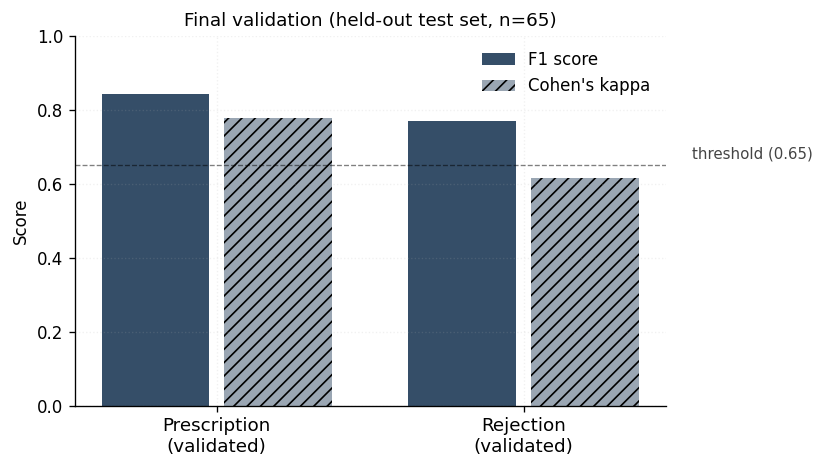

In [31]:
# validation summary plot

include = ['Prescription', 'Rejection']  # crisis and hate excluded
n_test = len(df_test)
f1_scores = [confirmatory_results[t]['f1']    for t in include]
kappas    = [confirmatory_results[t]['kappa']  for t in include]
colors    = [NAVY if f >= 0.65 else SLATE for f in f1_scores]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(include))
bars = ax.bar(x - 0.2, f1_scores, 0.35, label='F1 score', color=colors, alpha=0.9)
ax.bar(x + 0.2, kappas, 0.35, label="Cohen's kappa", color=colors, alpha=0.45, hatch='///')
ax.axhline(0.65, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(1.55, 0.66, 'threshold (0.65)', fontsize=9, color='#444', va='bottom')
ax.set_xticks(x)
ax.set_xticklabels([
    f'{t}\n(validated)' if confirmatory_results[t]['f1'] >= 0.65 else f'{t}\n(indicative)'
    for t in include
], fontsize=11)
ax.set_ylabel('Score')
ax.tick_params(axis='y', labelsize=10)
ax.set_ylim(0, 1.0)
ax.legend(frameon=False)
ax.set_title(f'Final validation (held-out test set, n={n_test})', fontsize=11)
plt.tight_layout()
plt.show()

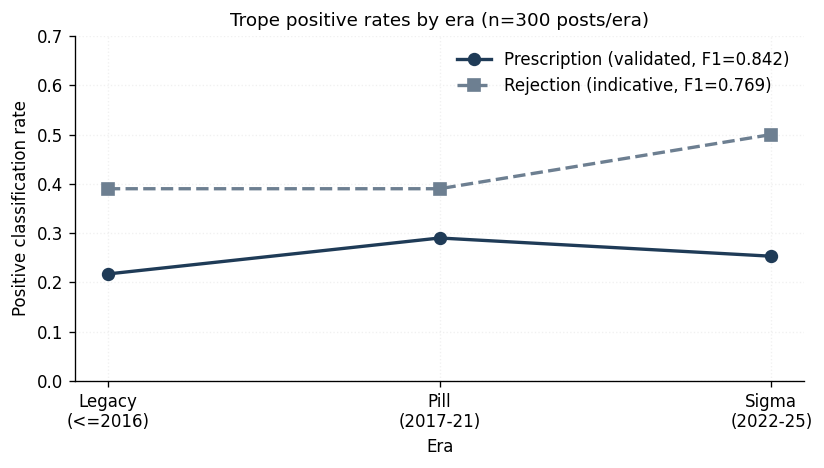

In [28]:
# plot positive classification rates by era
era_order = ['Legacy', 'Pill', 'Sigma']
era_labels_diag = ['Legacy\n(<=2016)', 'Pill\n(2017-21)', 'Sigma\n(2022-25)']
n_era_diag = audit_df.groupby('Era').size().min()

prescription_rates = [rates['Prescription'][era] for era in era_order]
rejection_rates    = [rates['Rejection'][era]    for era in era_order]

p_f1 = round(confirmatory_results['Prescription']['f1'], 3)
r_f1 = round(confirmatory_results['Rejection']['f1'], 3)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(era_labels_diag, prescription_rates, 'o-', color=NAVY, linewidth=2, markersize=7,
        label=f'Prescription (validated, F1={p_f1})')
ax.plot(era_labels_diag, rejection_rates, 's--', color=SLATE, linewidth=2, markersize=7,
        label=f'Rejection (indicative, F1={r_f1})')
ax.set_ylabel('Positive classification rate')
ax.set_xlabel('Era')
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(0, 0.7)
ax.legend(frameon=False)
ax.set_title(f'Trope positive rates by era (n={n_era_diag} posts/era)', fontsize=11)
plt.tight_layout()
plt.show()

In [29]:
# count how many missed rejection cases fall into each language group
if 'rejection_fn' in dir() and not rejection_fn.empty and 'subcultural_match' in rejection_fn.columns:
    n_sub  = int(rejection_fn['subcultural_match'].sum())
    n_gen  = int(rejection_fn['generic_match'].sum())
    n_neither = len(rejection_fn) - n_sub - n_gen
    count_source = 'live Section 5 output'
else:
    n_sub, n_gen, n_neither = 1, 0, 6
    count_source = 'fallback from saved May 2026 Section 5 run'

rejection_fn_counts = [n_sub, n_gen, n_neither]

pd.DataFrame({
    'category': ['subcultural marker', 'generic self-help/dating term', 'neither'],
    'count': rejection_fn_counts,
    'source': count_source
})

,category,count,source
0,subcultural marker,1,fallback from saved May 2026 Section 5 run
1,generic self-help/dating term,0,fallback from saved May 2026 Section 5 run
2,neither,6,fallback from saved May 2026 Section 5 run


## 7. Limitations and scope
This notebook uses LLM classification as a tool for checking trope patterns, not as automatic ground truth. The results, therefore, depend on the quality of the hand-coded gold standard and on the clarity of the trope definitions.

There are four main limitations.

First, the gold standard is relatively small and single-coded. This is enough for a capstone-scale validation exercise, but it means the scores show agreement between my coding and the classifier, not full intercoder reliability.

Second, the trope labels are uneven. Prescription and Rejection have enough signal to interpret, but Crisis and Hate are too sparse or unstable to support prevalence findings.

Third, the classifier only sees Reddit post titles. This makes the task harder because titles often imply ideology through framing, irony or advice language rather than explicit keywords.

Finally, the false-negative register check is diagnostic rather than a second classifier. It helps interpret why the model misses some Rejection cases, but it should not be treated as a full linguistic model of register shift.

Overall, the notebook is used to identify which LLM outputs are sufficiently reliable to support the capstone argument and which outputs require qualitative interpretation.terpretation.
